<a href="https://colab.research.google.com/github/p12Ivy0/PLTMH-ELC-QLSTM/blob/main/notebooks/03_validate_elc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import sys

REPO_URL = "https://github.com/p12Ivy0/PLTMH-ELC-QLSTM"
PROJECT_DIR = Path("/content/PLTMH-ELC-QLSTM")

if not PROJECT_DIR.exists():
    %cd /content
    !git clone {REPO_URL}

%cd /content/PLTMH-ELC-QLSTM

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("\nProject directory:")
!pwd

/content
Cloning into 'PLTMH-ELC-QLSTM'...
remote: Enumerating objects: 234, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 234 (delta 44), reused 32 (delta 19), pack-reused 165 (from 1)
Receiving objects: 100% (234/234), 505.50 KiB | 12.64 MiB/s, done.
Resolving deltas: 100% (106/106), done.
/content/PLTMH-ELC-QLSTM

Project directory:
/content/PLTMH-ELC-QLSTM


In [2]:
%cd /content/PLTMH-ELC-QLSTM

!git fetch origin
!git pull --rebase origin main

print("\n=== GIT STATUS ===")
!git status

/content/PLTMH-ELC-QLSTM
From https://github.com/p12Ivy0/PLTMH-ELC-QLSTM
 * branch            main       -> FETCH_HEAD
Already up to date.

=== GIT STATUS ===
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [3]:
print("=== ELC FILES ===")

!ls -lh src/plant/elc.py
!ls -lh src/plant/dump_load.py
!ls -lh tests/test_elc.py

=== ELC FILES ===
-rw-r--r-- 1 root root 1 Sep  5 10:28 src/plant/elc.py
-rw-r--r-- 1 root root 1 Sep  5 10:28 src/plant/dump_load.py
-rw-r--r-- 1 root root 1 Sep  5 10:28 tests/test_elc.py


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

NumPy : 2.1.3
Pandas: 2.2.3


In [5]:
%%writefile /content/PLTMH-ELC-QLSTM/src/plant/dump_load.py

from dataclasses import dataclass

import numpy as np


@dataclass(frozen=True)
class DumpLoadParams:
    """
    Parameter resistive dump load untuk ELC PLTMH.
    """

    rated_power_kw: float = 100.0
    duty_min: float = 0.0
    duty_max: float = 1.0

    def __post_init__(self):

        if self.rated_power_kw <= 0.0:
            raise ValueError(
                "rated_power_kw must be positive."
            )

        if not (
            0.0 <= self.duty_min
            < self.duty_max
            <= 1.0
        ):
            raise ValueError(
                "Duty limits must satisfy "
                "0 <= duty_min < duty_max <= 1."
            )


def clamp_duty(
    duty,
    params: DumpLoadParams
):
    """
    Membatasi duty cycle pada rentang fisik ELC.
    """

    value = np.clip(
        np.asarray(duty, dtype=float),
        params.duty_min,
        params.duty_max,
    )

    if value.ndim == 0:
        return float(value)

    return value


def average_dump_power_kw(
    duty,
    params: DumpLoadParams
):
    """
    Averaged PWM/IGBT dump-load model:

        P_dump = D * P_dump,rated
    """

    duty_clamped = clamp_duty(
        duty,
        params
    )

    power = (
        np.asarray(duty_clamped)
        * params.rated_power_kw
    )

    if power.ndim == 0:
        return float(power)

    return power


def required_duty_for_dump_power(
    power_kw,
    params: DumpLoadParams
):
    """
    Duty cycle yang diperlukan untuk menghasilkan
    daya dump-load tertentu.
    """

    duty = (
        np.asarray(power_kw, dtype=float)
        / params.rated_power_kw
    )

    return clamp_duty(
        duty,
        params
    )

Overwriting /content/PLTMH-ELC-QLSTM/src/plant/dump_load.py


In [6]:
!wc -l src/plant/dump_load.py
!head -n 20 src/plant/dump_load.py

98 src/plant/dump_load.py

from dataclasses import dataclass

import numpy as np


@dataclass(frozen=True)
class DumpLoadParams:
    """
    Parameter resistive dump load untuk ELC PLTMH.
    """

    rated_power_kw: float = 100.0
    duty_min: float = 0.0
    duty_max: float = 1.0

    def __post_init__(self):

        if self.rated_power_kw <= 0.0:
            raise ValueError(


In [7]:
%%writefile /content/PLTMH-ELC-QLSTM/src/plant/elc.py

from dataclasses import dataclass, field
from typing import Callable, Optional

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

from .dump_load import (
    DumpLoadParams,
    average_dump_power_kw,
    clamp_duty,
)


@dataclass(frozen=True)
class ELCParams:
    """
    Parameter averaged Electronic Load Controller.
    """

    dump_load: DumpLoadParams = field(
        default_factory=DumpLoadParams
    )

    actuator_time_constant_s: float = 0.05

    def __post_init__(self):

        if self.actuator_time_constant_s <= 0.0:
            raise ValueError(
                "actuator_time_constant_s "
                "must be positive."
            )


def required_dump_power_kw(
    generator_power_kw: float,
    consumer_power_kw: float,
    params: ELCParams,
) -> float:
    """
    Ideal dump power agar:

        P_gen = P_consumer + P_dump

    Dengan batas fisik dump load.
    """

    required = (
        float(generator_power_kw)
        - float(consumer_power_kw)
    )

    required = np.clip(
        required,
        0.0,
        params.dump_load.rated_power_kw,
    )

    return float(required)


def ideal_balance_duty(
    generator_power_kw: float,
    consumer_power_kw: float,
    params: ELCParams,
) -> float:
    """
    Duty-cycle ideal untuk menjaga keseimbangan daya.
    """

    dump_power = required_dump_power_kw(
        generator_power_kw,
        consumer_power_kw,
        params,
    )

    duty = (
        dump_power
        / params.dump_load.rated_power_kw
    )

    return clamp_duty(
        duty,
        params.dump_load,
    )


def elc_actuator_rhs(
    t: float,
    x: np.ndarray,
    params: ELCParams,
    duty_profile: Callable[[float], float],
) -> np.ndarray:
    """
    First-order averaged ELC actuator.

    State:
        x[0] = actual dump-load power [kW]
    """

    actual_dump_kw = float(x[0])

    duty = clamp_duty(
        duty_profile(t),
        params.dump_load,
    )

    commanded_dump_kw = average_dump_power_kw(
        duty,
        params.dump_load,
    )

    d_dump_dt = (
        commanded_dump_kw
        - actual_dump_kw
    ) / params.actuator_time_constant_s

    return np.array([
        d_dump_dt
    ])


def simulate_elc_actuator(
    params: ELCParams,
    duty_profile: Callable[[float], float],
    t_end_s: float = 5.0,
    dt_s: float = 0.005,
    initial_dump_power_kw: float = 0.0,
) -> pd.DataFrame:
    """
    Simulasi averaged ELC actuator.
    """

    n_steps = int(
        round(t_end_s / dt_s)
    )

    t_eval = np.linspace(
        0.0,
        t_end_s,
        n_steps + 1,
    )

    solution = solve_ivp(
        fun=lambda t, x: elc_actuator_rhs(
            t,
            x,
            params,
            duty_profile,
        ),
        t_span=(0.0, t_end_s),
        y0=np.array([
            float(initial_dump_power_kw)
        ]),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
        max_step=dt_s,
    )

    if not solution.success:
        raise RuntimeError(
            solution.message
        )

    time_s = solution.t

    duty = np.array([
        clamp_duty(
            duty_profile(t),
            params.dump_load,
        )
        for t in time_s
    ])

    command_kw = average_dump_power_kw(
        duty,
        params.dump_load,
    )

    actual_kw = solution.y[0]

    return pd.DataFrame({
        "time_s": time_s,
        "duty": duty,
        "dump_command_kw": command_kw,
        "dump_power_kw": actual_kw,
    })


def simulate_elc_balance(
    params: ELCParams,
    generator_power_profile: Callable[[float], float],
    consumer_power_profile: Callable[[float], float],
    t_end_s: float = 5.0,
    dt_s: float = 0.005,
    initial_dump_power_kw: Optional[float] = None,
) -> pd.DataFrame:
    """
    Validasi ideal ELC balancing.

    CATATAN:
    Fungsi ini belum menggunakan PI.

    Duty dihitung dari keseimbangan daya ideal
    hanya untuk memvalidasi arah dan kemampuan
    actuator ELC.
    """

    def duty_profile(t: float) -> float:

        return ideal_balance_duty(
            generator_power_profile(t),
            consumer_power_profile(t),
            params,
        )

    if initial_dump_power_kw is None:

        initial_dump_power_kw = (
            average_dump_power_kw(
                duty_profile(0.0),
                params.dump_load,
            )
        )

    result = simulate_elc_actuator(
        params=params,
        duty_profile=duty_profile,
        t_end_s=t_end_s,
        dt_s=dt_s,
        initial_dump_power_kw=initial_dump_power_kw,
    )

    t = result["time_s"].to_numpy()

    generator_kw = np.array([
        generator_power_profile(time)
        for time in t
    ])

    consumer_kw = np.array([
        consumer_power_profile(time)
        for time in t
    ])

    total_electrical_kw = (
        consumer_kw
        + result["dump_power_kw"].to_numpy()
    )

    power_balance_error_kw = (
        generator_kw
        - total_electrical_kw
    )

    result["generator_power_kw"] = generator_kw
    result["consumer_power_kw"] = consumer_kw
    result["total_electrical_load_kw"] = (
        total_electrical_kw
    )

    result["power_balance_error_kw"] = (
        power_balance_error_kw
    )

    return result

Overwriting /content/PLTMH-ELC-QLSTM/src/plant/elc.py


In [8]:
!wc -l src/plant/elc.py
!head -n 25 src/plant/elc.py

270 src/plant/elc.py

from dataclasses import dataclass, field
from typing import Callable, Optional

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

from .dump_load import (
    DumpLoadParams,
    average_dump_power_kw,
    clamp_duty,
)


@dataclass(frozen=True)
class ELCParams:
    """
    Parameter averaged Electronic Load Controller.
    """

    dump_load: DumpLoadParams = field(
        default_factory=DumpLoadParams
    )



In [9]:
from pathlib import Path

init_file = Path(
    "/content/PLTMH-ELC-QLSTM/src/plant/__init__.py"
)

text = init_file.read_text()

dump_import = """

from .dump_load import (
    DumpLoadParams,
    clamp_duty,
    average_dump_power_kw,
    required_duty_for_dump_power,
)
"""

elc_import = """

from .elc import (
    ELCParams,
    required_dump_power_kw,
    ideal_balance_duty,
    elc_actuator_rhs,
    simulate_elc_actuator,
    simulate_elc_balance,
)
"""

if "from .dump_load import" not in text:

    text += dump_import

if "from .elc import" not in text:

    text += elc_import

init_file.write_text(text)

print(
    "PASS: plant exports updated."
)

PASS: plant exports updated.


In [10]:
!cat src/plant/__init__.py


from .microhydro_plant import (
    PlantParams,
    hydraulic_power_w,
    mechanical_power_w,
    nominal_flow_m3_s,
    constant_profile,
    step_profile,
    plant_rhs,
    simulate_plant,
)


from .synchronous_generator import (
    GeneratorParams,
    electrical_base_speed_rad_s,
    synchronous_speed_rpm,
    frequency_hz,
    rotor_speed_rpm,
    generator_rhs,
    simulate_generator,
)


from .dump_load import (
    DumpLoadParams,
    clamp_duty,
    average_dump_power_kw,
    required_duty_for_dump_power,
)


from .elc import (
    ELCParams,
    required_dump_power_kw,
    ideal_balance_duty,
    elc_actuator_rhs,
    simulate_elc_actuator,
    simulate_elc_balance,
)


In [11]:
from src.plant import (
    DumpLoadParams,
    ELCParams,
    clamp_duty,
    average_dump_power_kw,
    required_dump_power_kw,
    ideal_balance_duty,
    simulate_elc_actuator,
    simulate_elc_balance,
)

print(
    "PASS: ELC modules berhasil di-import."
)

PASS: ELC modules berhasil di-import.


In [12]:
dump_params = DumpLoadParams(
    rated_power_kw=100.0
)

elc_params = ELCParams(
    dump_load=dump_params,
    actuator_time_constant_s=0.05,
)

print(dump_params)
print(elc_params)

DumpLoadParams(rated_power_kw=100.0, duty_min=0.0, duty_max=1.0)
ELCParams(dump_load=DumpLoadParams(rated_power_kw=100.0, duty_min=0.0, duty_max=1.0), actuator_time_constant_s=0.05)


In [13]:
test_duty = np.array([
    -0.2,
    0.0,
    0.25,
    0.50,
    0.75,
    1.0,
    1.2,
])

clipped = clamp_duty(
    test_duty,
    dump_params
)

power = average_dump_power_kw(
    test_duty,
    dump_params
)

validation_table = pd.DataFrame({
    "input_duty": test_duty,
    "clipped_duty": clipped,
    "dump_power_kw": power,
})

validation_table

,input_duty,clipped_duty,dump_power_kw
0,-0.20,0.00,0.0
1,0.00,0.00,0.0
2,0.25,0.25,25.0
3,0.50,0.50,50.0
4,0.75,0.75,75.0
5,1.00,1.00,100.0
6,1.20,1.00,100.0


In [14]:
assert np.isclose(
    average_dump_power_kw(
        0.0,
        dump_params
    ),
    0.0
)

assert np.isclose(
    average_dump_power_kw(
        0.5,
        dump_params
    ),
    50.0
)

assert np.isclose(
    average_dump_power_kw(
        1.0,
        dump_params
    ),
    100.0
)

assert np.isclose(
    average_dump_power_kw(
        1.5,
        dump_params
    ),
    100.0
)

print(
    "PASS: dump-load static mapping valid."
)

PASS: dump-load static mapping valid.


In [15]:
generator_kw = 100.0
consumer_kw = 80.0

required_dump = required_dump_power_kw(
    generator_kw,
    consumer_kw,
    elc_params,
)

required_duty = ideal_balance_duty(
    generator_kw,
    consumer_kw,
    elc_params,
)

print(
    f"Generator power : "
    f"{generator_kw:.2f} kW"
)

print(
    f"Consumer power  : "
    f"{consumer_kw:.2f} kW"
)

print(
    f"Required dump   : "
    f"{required_dump:.2f} kW"
)

print(
    f"Required duty   : "
    f"{required_duty:.3f}"
)

Generator power : 100.00 kW
Consumer power  : 80.00 kW
Required dump   : 20.00 kW
Required duty   : 0.200


In [16]:
assert np.isclose(
    required_dump,
    20.0
)

assert np.isclose(
    required_duty,
    0.20
)

assert np.isclose(
    consumer_kw + required_dump,
    generator_kw
)

print(
    "PASS: ideal ELC power balance valid."
)

PASS: ideal ELC power balance valid.


In [17]:
generator_profile = (
    lambda t: 100.0
)

consumer_load_drop = (
    lambda t:
    80.0 if t < 2.0
    else 60.0
)

df_load_drop = simulate_elc_balance(
    params=elc_params,
    generator_power_profile=generator_profile,
    consumer_power_profile=consumer_load_drop,
    t_end_s=5.0,
    dt_s=0.005,
)

df_load_drop.head()

,time_s,duty,dump_command_kw,dump_power_kw,generator_power_kw,consumer_power_kw,total_electrical_load_kw,power_balance_error_kw
0,0.000,0.2,20.0,20.0,100.0,80.0,100.0,0.0
1,0.005,0.2,20.0,20.0,100.0,80.0,100.0,0.0
2,0.010,0.2,20.0,20.0,100.0,80.0,100.0,0.0
3,0.015,0.2,20.0,20.0,100.0,80.0,100.0,0.0
4,0.020,0.2,20.0,20.0,100.0,80.0,100.0,0.0


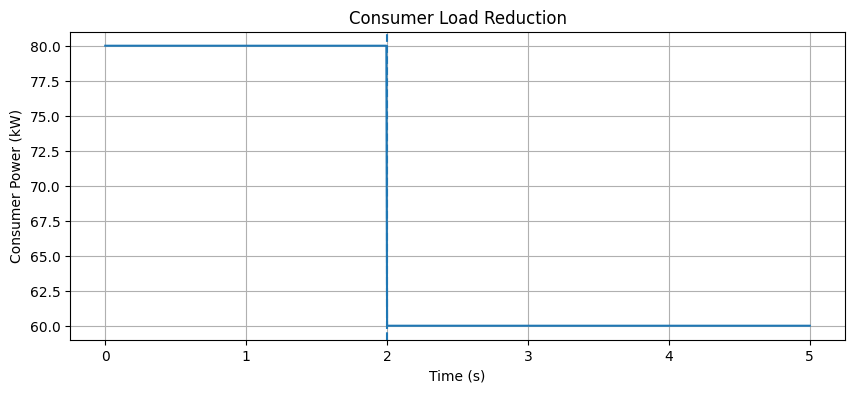

In [18]:
plt.figure(figsize=(10, 4))

plt.plot(
    df_load_drop["time_s"],
    df_load_drop["consumer_power_kw"]
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Consumer Power (kW)")
plt.title(
    "Consumer Load Reduction"
)

plt.grid(True)
plt.show()

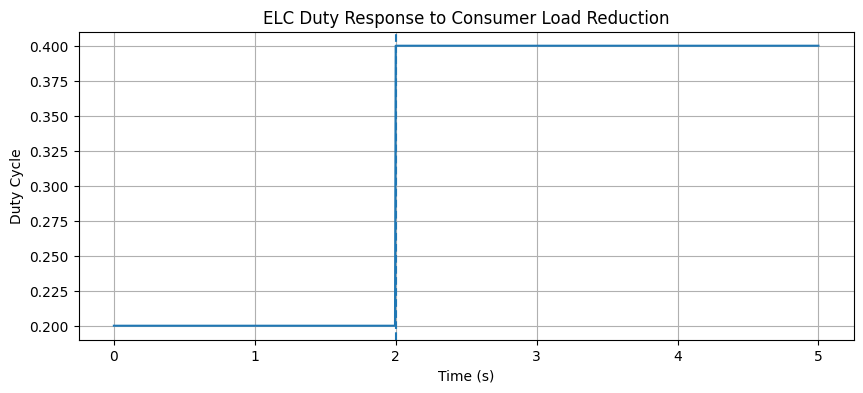

In [19]:
plt.figure(figsize=(10, 4))

plt.plot(
    df_load_drop["time_s"],
    df_load_drop["duty"]
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Duty Cycle")
plt.title(
    "ELC Duty Response to Consumer Load Reduction"
)

plt.grid(True)
plt.show()

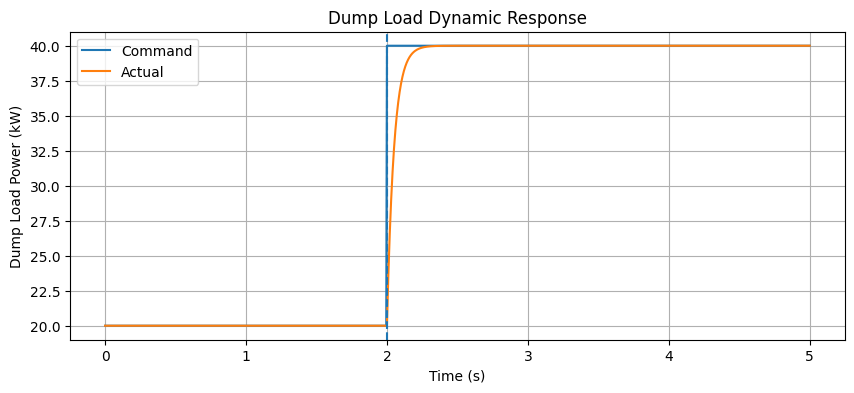

In [20]:
plt.figure(figsize=(10, 4))

plt.plot(
    df_load_drop["time_s"],
    df_load_drop["dump_command_kw"],
    label="Command"
)

plt.plot(
    df_load_drop["time_s"],
    df_load_drop["dump_power_kw"],
    label="Actual"
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Dump Load Power (kW)")
plt.title(
    "Dump Load Dynamic Response"
)

plt.legend()
plt.grid(True)
plt.show()

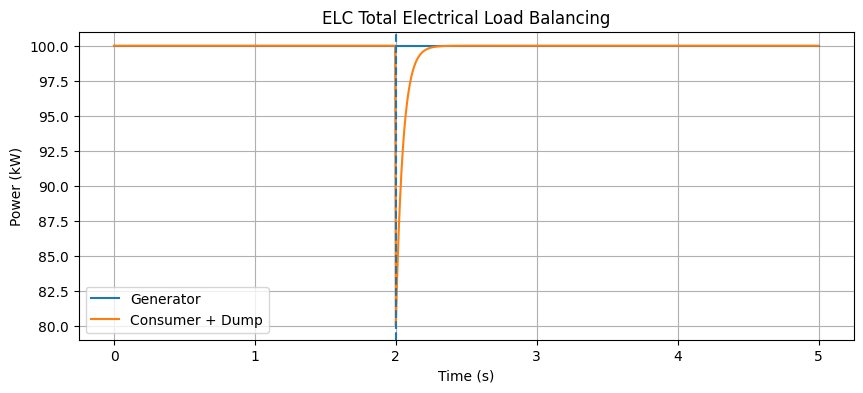

In [21]:
plt.figure(figsize=(10, 4))

plt.plot(
    df_load_drop["time_s"],
    df_load_drop["generator_power_kw"],
    label="Generator"
)

plt.plot(
    df_load_drop["time_s"],
    df_load_drop["total_electrical_load_kw"],
    label="Consumer + Dump"
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Power (kW)")
plt.title(
    "ELC Total Electrical Load Balancing"
)

plt.legend()
plt.grid(True)
plt.show()

In [22]:
final_drop_power = (
    df_load_drop[
        "dump_power_kw"
    ].iloc[-1]
)

final_balance_error = (
    df_load_drop[
        "power_balance_error_kw"
    ].iloc[-1]
)

print(
    f"Final dump power    : "
    f"{final_drop_power:.6f} kW"
)

print(
    f"Final balance error : "
    f"{final_balance_error:.6f} kW"
)

assert np.isclose(
    final_drop_power,
    40.0,
    atol=0.01
)

assert abs(
    final_balance_error
) < 0.01

print(
    "PASS: ELC compensates consumer load reduction."
)

Final dump power    : 40.000000 kW
Final balance error : 0.000000 kW
PASS: ELC compensates consumer load reduction.


In [23]:
consumer_load_increase = (
    lambda t:
    60.0 if t < 2.0
    else 90.0
)

df_load_increase = simulate_elc_balance(
    params=elc_params,
    generator_power_profile=generator_profile,
    consumer_power_profile=consumer_load_increase,
    t_end_s=5.0,
    dt_s=0.005,
)

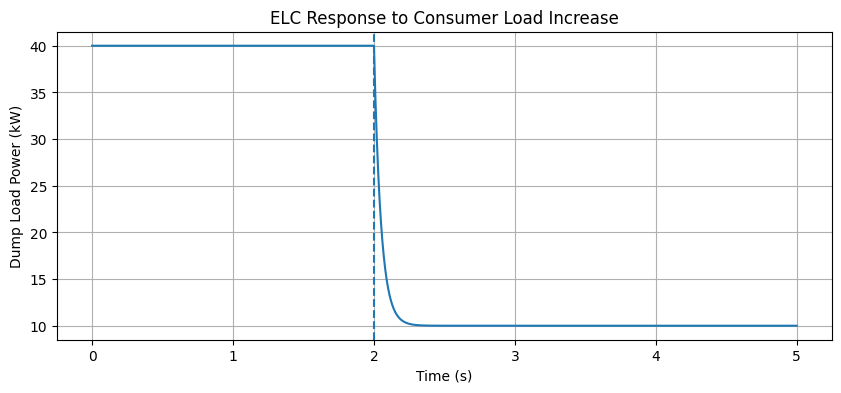

In [24]:
plt.figure(figsize=(10, 4))

plt.plot(
    df_load_increase["time_s"],
    df_load_increase["dump_power_kw"]
)

plt.axvline(
    2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Dump Load Power (kW)")
plt.title(
    "ELC Response to Consumer Load Increase"
)

plt.grid(True)
plt.show()

In [25]:
pre_drop = df_load_drop.loc[
    df_load_drop["time_s"] < 1.9,
    "dump_power_kw"
].iloc[-1]

post_drop = (
    df_load_drop[
        "dump_power_kw"
    ].iloc[-1]
)

pre_increase = df_load_increase.loc[
    df_load_increase["time_s"] < 1.9,
    "dump_power_kw"
].iloc[-1]

post_increase = (
    df_load_increase[
        "dump_power_kw"
    ].iloc[-1]
)

assert post_drop > pre_drop
assert post_increase < pre_increase

print(
    "PASS: ELC response direction valid."
)

PASS: ELC response direction valid.


In [26]:
case_overcapacity = ideal_balance_duty(
    generator_power_kw=120.0,
    consumer_power_kw=0.0,
    params=elc_params,
)

case_consumer_above_gen = ideal_balance_duty(
    generator_power_kw=100.0,
    consumer_power_kw=120.0,
    params=elc_params,
)

print(
    "Generator 120 kW, consumer 0 kW:",
    case_overcapacity
)

print(
    "Generator 100 kW, consumer 120 kW:",
    case_consumer_above_gen
)

assert np.isclose(
    case_overcapacity,
    1.0
)

assert np.isclose(
    case_consumer_above_gen,
    0.0
)

print(
    "PASS: ELC duty saturation valid."
)

Generator 120 kW, consumer 0 kW: 1.0
Generator 100 kW, consumer 120 kW: 0.0
PASS: ELC duty saturation valid.


In [27]:
%%writefile /content/PLTMH-ELC-QLSTM/tests/test_elc.py

import numpy as np

from src.plant import (
    DumpLoadParams,
    ELCParams,
    clamp_duty,
    average_dump_power_kw,
    required_dump_power_kw,
    ideal_balance_duty,
    simulate_elc_balance,
)


def make_params():

    return ELCParams(
        dump_load=DumpLoadParams(
            rated_power_kw=100.0
        ),
        actuator_time_constant_s=0.05,
    )


def test_duty_clipping():

    params = DumpLoadParams()

    assert clamp_duty(-0.2, params) == 0.0
    assert clamp_duty(1.2, params) == 1.0


def test_dump_power_mapping():

    params = DumpLoadParams(
        rated_power_kw=100.0
    )

    assert np.isclose(
        average_dump_power_kw(
            0.0,
            params
        ),
        0.0
    )

    assert np.isclose(
        average_dump_power_kw(
            0.5,
            params
        ),
        50.0
    )

    assert np.isclose(
        average_dump_power_kw(
            1.0,
            params
        ),
        100.0
    )


def test_required_dump_power():

    params = make_params()

    power = required_dump_power_kw(
        generator_power_kw=100.0,
        consumer_power_kw=80.0,
        params=params,
    )

    assert np.isclose(
        power,
        20.0
    )


def test_ideal_balance_duty():

    params = make_params()

    duty = ideal_balance_duty(
        generator_power_kw=100.0,
        consumer_power_kw=80.0,
        params=params,
    )

    assert np.isclose(
        duty,
        0.20
    )


def test_load_reduction_increases_dump_load():

    params = make_params()

    result = simulate_elc_balance(
        params=params,
        generator_power_profile=lambda t: 100.0,
        consumer_power_profile=lambda t: (
            80.0 if t < 1.0 else 60.0
        ),
        t_end_s=3.0,
        dt_s=0.005,
    )

    pre = result.loc[
        result["time_s"] < 0.9,
        "dump_power_kw"
    ].iloc[-1]

    post = result[
        "dump_power_kw"
    ].iloc[-1]

    assert post > pre

    assert np.isclose(
        post,
        40.0,
        atol=0.01
    )


def test_load_increase_decreases_dump_load():

    params = make_params()

    result = simulate_elc_balance(
        params=params,
        generator_power_profile=lambda t: 100.0,
        consumer_power_profile=lambda t: (
            60.0 if t < 1.0 else 90.0
        ),
        t_end_s=3.0,
        dt_s=0.005,
    )

    pre = result.loc[
        result["time_s"] < 0.9,
        "dump_power_kw"
    ].iloc[-1]

    post = result[
        "dump_power_kw"
    ].iloc[-1]

    assert post < pre

    assert np.isclose(
        post,
        10.0,
        atol=0.01
    )


def test_power_balance_settles():

    params = make_params()

    result = simulate_elc_balance(
        params=params,
        generator_power_profile=lambda t: 100.0,
        consumer_power_profile=lambda t: (
            80.0 if t < 1.0 else 60.0
        ),
        t_end_s=3.0,
        dt_s=0.005,
    )

    final_error = (
        result[
            "power_balance_error_kw"
        ].iloc[-1]
    )

    assert abs(
        final_error
    ) < 0.01


def test_elc_saturation():

    params = make_params()

    high = ideal_balance_duty(
        generator_power_kw=120.0,
        consumer_power_kw=0.0,
        params=params,
    )

    low = ideal_balance_duty(
        generator_power_kw=100.0,
        consumer_power_kw=120.0,
        params=params,
    )

    assert high == 1.0
    assert low == 0.0

Overwriting /content/PLTMH-ELC-QLSTM/tests/test_elc.py


In [28]:
%cd /content/PLTMH-ELC-QLSTM

!PYTHONPATH=/content/PLTMH-ELC-QLSTM \
python -m pytest -q tests/test_elc.py

/content/PLTMH-ELC-QLSTM
........                                                                 [100%]
8 passed in 2.89s


In [29]:
!PYTHONPATH=/content/PLTMH-ELC-QLSTM \
python -m pytest -q tests/test_generator.py

.....                                                                    [100%]
5 passed in 1.42s


In [30]:
!PYTHONPATH=/content/PLTMH-ELC-QLSTM \
python -m pytest -q tests/test_plant_model.py

....                                                                     [100%]
4 passed in 1.95s


In [31]:
!PYTHONPATH=/content/PLTMH-ELC-QLSTM \
python -m pytest -q

.................                                                        [100%]
17 passed in 2.95s


In [32]:
%cd /content/PLTMH-ELC-QLSTM

!git status

/content/PLTMH-ELC-QLSTM
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   src/plant/__init__.py
	modified:   src/plant/dump_load.py
	modified:   src/plant/elc.py
	modified:   tests/test_elc.py

no changes added to commit (use "git add" and/or "git commit -a")


In [33]:
!git add src/plant/__init__.py
!git add src/plant/dump_load.py
!git add src/plant/elc.py
!git add tests/test_elc.py

!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   src/plant/__init__.py
	modified:   src/plant/dump_load.py
	modified:   src/plant/elc.py
	modified:   tests/test_elc.py



In [34]:
!git config --global user.name "p12Ivy0"
!git config --global user.email "ypriyogunos@gmail.com"

!git commit -m "Add averaged ELC and dump load validation model"

[main 53ab22a] Add averaged ELC and dump load validation model
 4 files changed, 585 insertions(+)


In [35]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [36]:
import shutil

gh_path = shutil.which("gh")

print(
    "GitHub CLI path:",
    gh_path
)

if gh_path is None:
    print(
        "GitHub CLI belum tersedia."
    )
else:
    print(
        "PASS: GitHub CLI tersedia."
    )

GitHub CLI path: /usr/bin/gh
PASS: GitHub CLI tersedia.


In [37]:
!gh --version

gh version 2.98.0 (2026-08-20)
https://github.com/cli/cli/releases/tag/v2.98.0


In [38]:
from google.colab import userdata

github_token = userdata.get(
    "GITHUB_TOKEN"
)

if github_token:
    print(
        "PASS: GITHUB_TOKEN berhasil dibaca "
        "dari Colab Secrets."
    )
else:
    raise RuntimeError(
        "GITHUB_TOKEN tidak ditemukan."
    )

PASS: GITHUB_TOKEN berhasil dibaca dari Colab Secrets.


In [39]:
import subprocess

auth_result = subprocess.run(
    [
        "gh",
        "auth",
        "login",
        "--hostname",
        "github.com",
        "--git-protocol",
        "https",
        "--with-token",
    ],
    input=github_token,
    text=True,
    capture_output=True,
)

if auth_result.returncode == 0:
    print(
        "PASS: autentikasi GitHub CLI berhasil."
    )
else:
    print(
        "GitHub authentication output:"
    )
    print(
        auth_result.stderr
    )

PASS: autentikasi GitHub CLI berhasil.


In [41]:
!gh auth setup-git

In [42]:
!gh auth status

github.com
  ✓ Logged in to github.com account p12Ivy0 (/root/.config/gh/hosts.yml)
  - Active account: true
  - Git operations protocol: https
  - Token: github_pat_**********************************************************************************


In [43]:
print(
    "=== GIT IDENTITY ==="
)

!git config --global user.name
!git config --global user.email

=== GIT IDENTITY ===
p12Ivy0
ypriyogunos@gmail.com


In [44]:
print(
    "=== REMOTE REPOSITORY ==="
)

!git remote -v

=== REMOTE REPOSITORY ===
origin	https://github.com/p12Ivy0/PLTMH-ELC-QLSTM (fetch)
origin	https://github.com/p12Ivy0/PLTMH-ELC-QLSTM (push)


In [45]:
!git ls-remote origin HEAD

db8cc8fd5b759595ad6a5737bdf69eedce1fef79	HEAD


In [46]:
%cd /content/PLTMH-ELC-QLSTM

!git fetch origin

/content/PLTMH-ELC-QLSTM


In [47]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [48]:
!git pull --rebase origin main

From https://github.com/p12Ivy0/PLTMH-ELC-QLSTM
 * branch            main       -> FETCH_HEAD
Current branch main is up to date.


In [49]:
!git log -8 --oneline --graph --decorate --all

* 53ab22a (HEAD -> main) Add averaged ELC and dump load validation model
* db8cc8f (origin/main, origin/HEAD) Add synchronous generator model and validation tests
* 2750f4d Update synchronous generator validation notebook
* cb5c612 Created using Colab
* dc8da34 Created using Colab
* 204ab76 Add reduced-order synchronous generator model and tests
* 9c7e638 Use canonical turbine validation notebook name
* 9511ded Created using Colab


In [50]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [51]:
!git push origin main

Enumerating objects: 17, done.
Counting objects: 100% (15/15), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 3.47 KiB | 3.47 MiB/s, done.
Total 9 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 5 local objects.
To https://github.com/p12Ivy0/PLTMH-ELC-QLSTM
   db8cc8f..53ab22a  main -> main


In [52]:
!git fetch origin
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [53]:
!git log -5 --oneline

53ab22a (HEAD -> main, origin/main, origin/HEAD) Add averaged ELC and dump load validation model
db8cc8f Add synchronous generator model and validation tests
2750f4d Update synchronous generator validation notebook
cb5c612 Created using Colab
dc8da34 Created using Colab
